# Машинное обучение, ФКН ВШЭ

# Практическое задание 6. Бустинговое

## Общая информация

Дата выдачи: 12.12.2024

Мягкий дедлайн: 22.12.2024 23:59 MSK

Жёсткий дедлайн: 22.12.2024 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-06-Username.ipynb

Username — ваша фамилия на латинице

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг. Однако с большой силой приходит и большая ответственность, так что заодно научимся, как его правильно готовить

In [1]:
from warnings import filterwarnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split

sns.set(style='darkgrid')
filterwarnings('ignore')

In [168]:
X = load_npz('x.npz')
y = np.load('y.npy')

Разделим на обучающую, валидационную и тестовую выборки (оставьте `random_state=1337` для воспроизводимости).

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=1337)

X_train.shape, X_valid.shape, X_test.shape

((18825, 169), (2354, 169), (2353, 169))

---

## Задание 1. Базовый градиентный бустинг (4 балла)

Первая часть посвящена реализации собственного градиентного бустинга. Обращаем внимание, что пользоваться готовыми реализациями <font color='lightcoral'>**нельзя**</font>, если специально не оговорено. На все <font color='plum'>**вопросы**</font> должен быть <font color='plum'>**ответ**</font>. В заданиях есть референсы для параметров, которые нужно сделать, на случай, если объяснение из ноутбука непонятно, тогда советуем обратиться к соответствующей документации

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

Обязательные параметры:
 — `base_model_class` — класс базовой модели нашего бустинга
 — `base_model_params` — словарь с гиперпараметрами для базовой модели
 — `n_estimators` — какое количество базовых моделей нужно обучить
 — `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`). После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах). После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

После всего цикла обучения надо нарисовать график (если `plot=True`).

#### `partial_fit`

В `partial_fit` приходит обучающая выборка, на которую обучается новая базовая модель

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

#### `plot_history`

В `plot_history` приходит любая выборка, для которой последовательно считаются значения функции потерь и/или любой метрики, которую вы хотите посчитать, путем последовательного применения базовых моделей. Можно делать сразу во время обучения, можно делать иначе

In [4]:
%load_ext autoreload

In [5]:
%autoreload 2

from boosting import Boosting

### Проверка кода

Total training time: 15.91 seconds


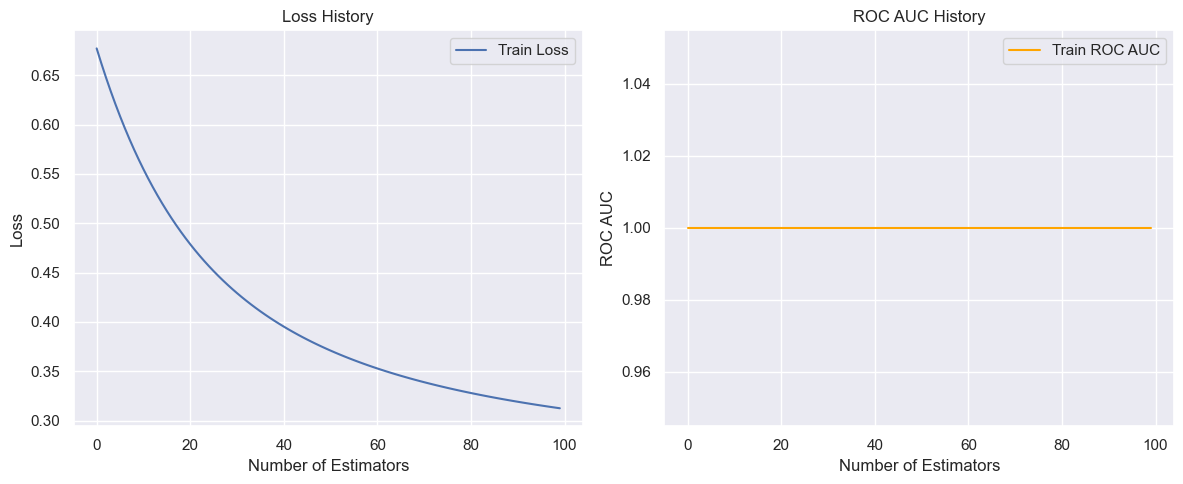

Train ROC-AUC 0.9998
Valid ROC-AUC 0.9071
Test ROC-AUC 0.9048


In [21]:
boosting = Boosting(n_estimators=100)

boosting.fit(X_train, y_train)
boosting.plot_history(X_valid, y_valid)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

---

## Задание 2. Имплементация гиперпараметров (2.5 балла + 3.5 бонус)

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации безотносительно базовой модели. В этом пункте предлагается имплементировать часть из них. При необходимости можете обратиться к реализациям в вашей любимой библиотеке, там могут быть дополнительные пояснения и/или ссылки на оригинальные статьи

<font color='lightcoral'>**Важно!**</font> После добавления каждого параметра проверьте, как это повлияет на качество. Специально крутить параметры не нужно, но важно увидеть, что перформанс модели изменился, в худшую или в лучшую сторону, для этого какие-то параметры нужны, пусть и от балды, <font color='lightcoral'>**дефолтные параметры не подойдут**</font>, они скорее для референса. Лучше всего это видно по графикам обучения <font color='lightcoral'>**на трейне и валидации**</font>, рекомендуется смотрить именно на них

### 2.1. Борьба с переобучением (0.5 балла)

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации. Реализуйте такую процедуру, не забудьте, что всю предобработку, что вы будете делать для трейна, нужно будет повторить на валидации

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| <td colspan=3>`early_stopping_rounds`, `eval_set` |

Добавьте параметры:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `X_val`, `y_val` или `eval_set: Tuple[np.ndarray] | None = None` — валидацонная выборка, на которой будем проверять переобучение

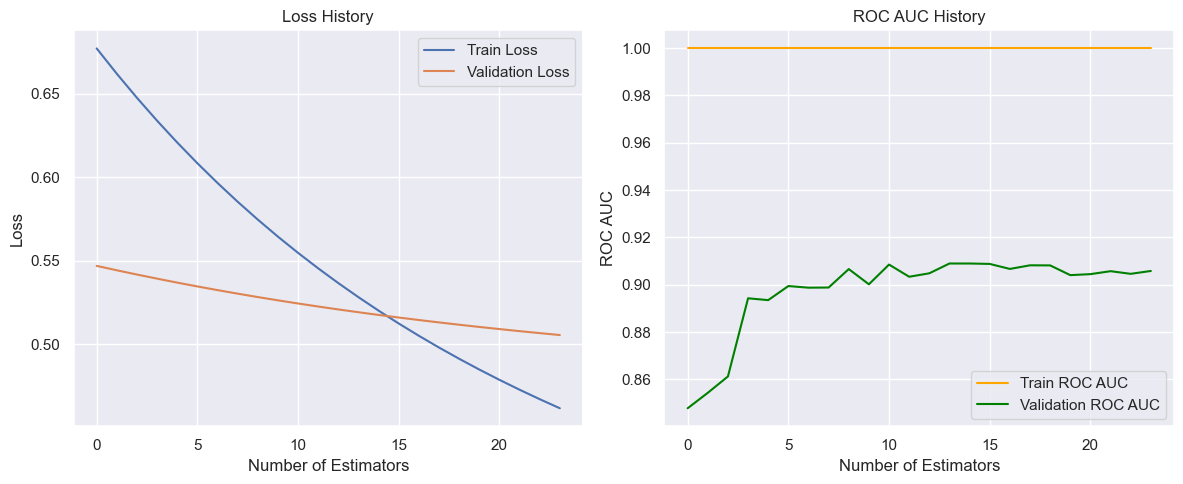

Train ROC-AUC: 0.9998
Valid ROC-AUC: 0.9058
Test ROC-AUC: 0.9036


In [10]:
boosting = Boosting(
    n_estimators=100,
    early_stopping_rounds=10
)

boosting.fit(X_train, y_train, X_valid, y_valid)
boosting.plot_history()

print(f'Train ROC-AUC: {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC: {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC: {boosting.score(X_test, y_test):.4f}')

### Бонус. Бустинг линейных моделей (0.5 балла)

**<font color='plum'>Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?</font>

<font color='plum'>**Ответ:** ...</font>

Давайте убедимся. Обучите бустинг, где в качестве базовой модели будет линейная регрессия. Обязательно сохраните историю функции потерь и зафиксируйте время обучения. Можно взять уже готовый из <font color='lightblue'>**XGBoost**</font>, но будьте готовы разобраться с тем, как оттуда достать историю обучения

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `XGBClassifier(booster="gblinear")` | — | — |

In [7]:
import sys
print("Python Executable:", sys.executable)


Python Executable: /opt/anaconda3/bin/python


In [7]:
!pip install xgboost

Train ROC-AUC: 0.9700
Valid ROC-AUC: 0.9403
Test ROC-AUC: 0.9382


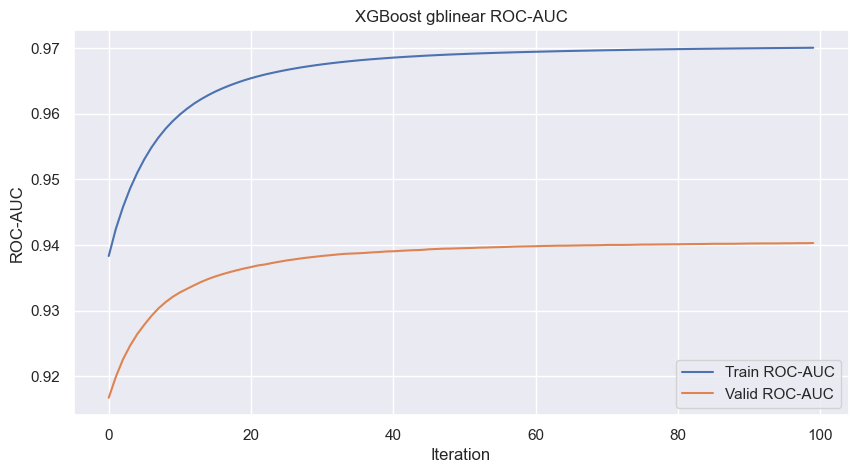

In [8]:
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt


model = xgb.XGBClassifier(
    booster='gblinear',
    n_estimators=100,
    learning_rate=0.1,
    early_stopping_rounds=10,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)

eval_set = [(X_train, y_train), (X_valid, y_valid)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

y_pred_train = model.predict_proba(X_train)[:, 1]
y_pred_valid = model.predict_proba(X_valid)[:, 1]
y_pred_test = model.predict_proba(X_test)[:, 1]

print(f'Train ROC-AUC: {roc_auc_score(y_train, y_pred_train):.4f}')
print(f'Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_valid):.4f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, y_pred_test):.4f}')

results = model.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['auc'], label='Train ROC-AUC')
plt.plot(x_axis, results['validation_1']['auc'], label='Valid ROC-AUC')
plt.xlabel('Iteration')
plt.ylabel('ROC-AUC')
plt.title('XGBoost gblinear ROC-AUC')
plt.legend()
plt.show()


Теперь возьмите `sklearn.linear_model.SGDClassifier` иобучите на тех же данных. Не забудьте вытащить историю функции потерь

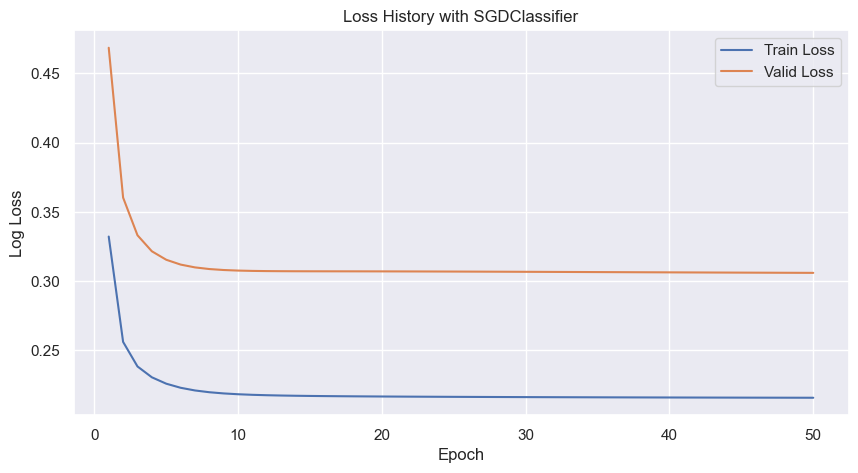

In [19]:
from sklearn.metrics import log_loss

sgd = SGDClassifier(
    loss='log_loss',
    learning_rate='optimal',
    max_iter=1,
    warm_start=True,
    random_state=42,
    tol=None
)

n_epochs = 50
train_loss_history = []
valid_loss_history = []

for epoch in range(n_epochs):
    sgd.partial_fit(X_train, y_train, classes=np.unique(y_train))
    
    y_train_pred_proba = sgd.predict_proba(X_train)[:, 1]
    y_valid_pred_proba = sgd.predict_proba(X_valid)[:, 1]
    
    train_loss = log_loss(y_train, y_train_pred_proba)
    valid_loss = log_loss(y_valid, y_valid_pred_proba)
    
    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    
    if epoch > 10:
        if valid_loss_history[-1] > min(valid_loss_history[-11:-1]):
            break

epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss_history, label='Train Loss')
plt.plot(epochs, valid_loss_history, label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Loss History with SGDClassifier')
plt.legend()
plt.grid(True)
plt.show()


Покажите на одном графике изменение функции потерь для бустинга и SGD классификатора. Сравните следующие параметры у бустинга и линейной модели:

- время обучения
- число итераций до сходимости
- графики функции потерь на трейне и на валидации

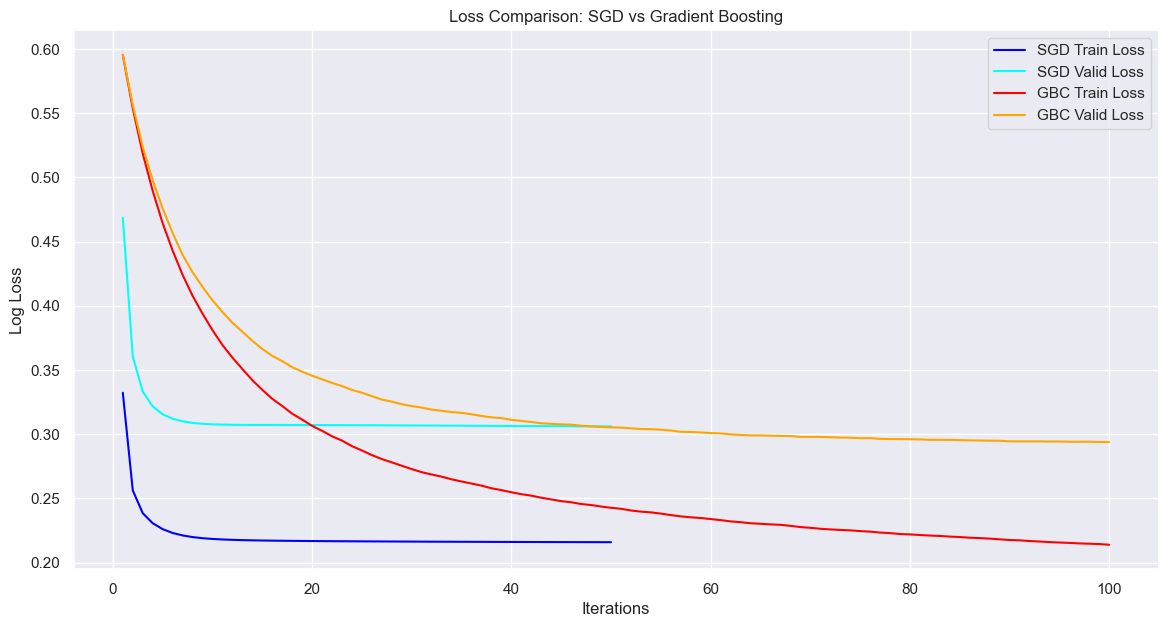

SGD Training Time: 0.22 seconds
SGD Iterations: 50
GBC Training Time: 0.88 seconds
GBC Iterations: 100


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import time

sgd = SGDClassifier(
    loss='log_loss',
    learning_rate='optimal',
    penalty='l2',
    max_iter=1,
    warm_start=True,
    random_state=42,
    tol=None
)

gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

n_epochs = 50
sgd_train_loss_history = []
sgd_valid_loss_history = []

start_time = time.time()
for epoch in range(n_epochs):
    sgd.partial_fit(X_train, y_train, classes=np.unique(y_train))
    
    y_train_pred_proba = sgd.predict_proba(X_train)[:, 1]
    y_valid_pred_proba = sgd.predict_proba(X_valid)[:, 1]
    
    train_loss = log_loss(y_train, y_train_pred_proba)
    valid_loss = log_loss(y_valid, y_valid_pred_proba)
    
    sgd_train_loss_history.append(train_loss)
    sgd_valid_loss_history.append(valid_loss)
    
    if epoch > 10 and valid_loss > min(sgd_valid_loss_history[-11:-1]):
        break
sgd_time = time.time() - start_time

start_time = time.time()
gbc.fit(X_train, y_train)
gbc_time = time.time() - start_time

gbc_train_loss_history = []
gbc_valid_loss_history = []

for y_pred_train, y_pred_valid in zip(gbc.staged_predict_proba(X_train), gbc.staged_predict_proba(X_valid)):
    gbc_train_loss_history.append(log_loss(y_train, y_pred_train[:, 1]))
    gbc_valid_loss_history.append(log_loss(y_valid, y_pred_valid[:, 1]))

plt.figure(figsize=(14, 7))
plt.plot(range(1, len(sgd_train_loss_history) + 1), sgd_train_loss_history, label='SGD Train Loss', color='blue')
plt.plot(range(1, len(sgd_valid_loss_history) + 1), sgd_valid_loss_history, label='SGD Valid Loss', color='cyan')
plt.plot(range(1, len(gbc_train_loss_history) + 1), gbc_train_loss_history, label='GBC Train Loss', color='red')
plt.plot(range(1, len(gbc_valid_loss_history) + 1), gbc_valid_loss_history, label='GBC Valid Loss', color='orange')

plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.title('Loss Comparison: SGD vs Gradient Boosting')
plt.legend()
plt.grid(True)
plt.show()

print(f"SGD Training Time: {sgd_time:.2f} seconds")
print(f"SGD Iterations: {len(sgd_train_loss_history)}")
print(f"GBC Training Time: {gbc_time:.2f} seconds")
print(f"GBC Iterations: {len(gbc_train_loss_history)}")


<font color='plum'>**Вопрос:** Какой вывод вы можете сделать?</font>

<font color='plum'>**Ответ:** Это сравнение показывает, что выбор модели может зависеть от требований к скорости обучения и точности. GradientBoostingClassifier может быть предпочтительным для более точных моделей, в то время как SGDClassifier может быть полезен для быстрого обучения.</font>

### 2.2. Бутстрап (0.5 балла)
Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `subsample`, — | `subsample`, `bagging`| `subsample`, `bootstrap_type`|

Вам нужно реализовать параметры:
- `subsample: float | int = 1.0` — доля или число объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float | int = 1.0` — веса объектов, которые попадают в выборку. Соответствует бутстрапу типа `Bayesian`. Каждый объект имеет определенный вес $t$, на который впоследствии домножается по формуле $w = (-\log(X))^t$, где $X \sim {U[0, 1]}$, после чего попадает в выборку. Таким образом можно сделать симуляцию повторений
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

<font color='plum'>**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?</font>

<font color='plum'>**Ответ:** Бутстрапирование может уменьшить смещение, так как каждая модель обучается на разных подвыборках, что позволяет лучше захватывать различные аспекты данных. Использование бутстрапа может увеличить разброс, так как каждая модель видит только часть данных. Однако, в бустинге это компенсируется за счет усреднения предсказаний множества моделей. Использование подвыборок данных может помочь снизить риск переобучения, так как каждая модель видит только часть данных и не может полностью подстроиться под все данные.</font>

Total training time: 2.63 seconds


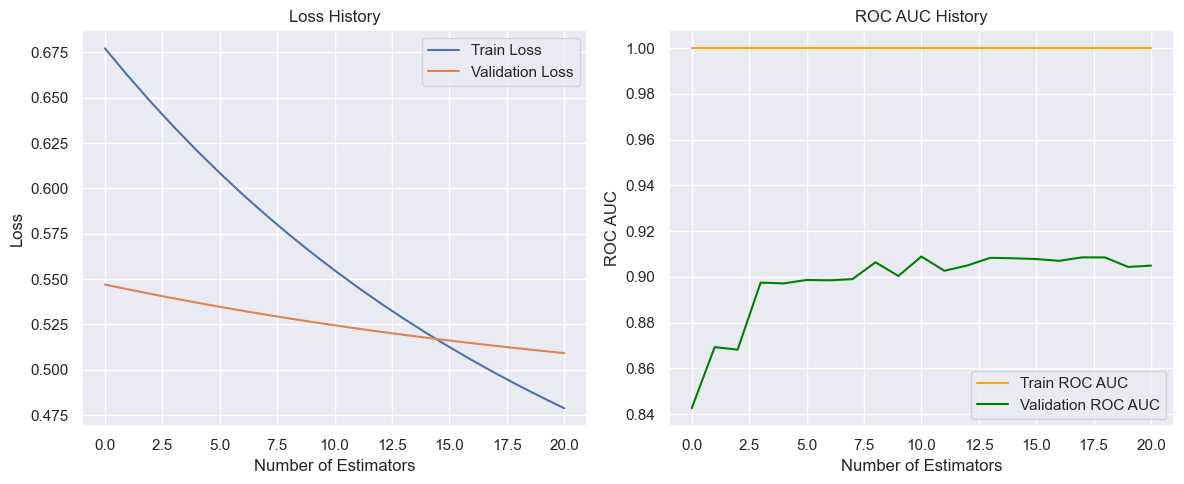

Train ROC-AUC: 0.9998
Valid ROC-AUC: 0.9049
Test ROC-AUC: 0.9029


In [24]:
boosting = Boosting(
    n_estimators=100,
    early_stopping_rounds=10
)

boosting.fit(X_train, y_train, X_valid, y_valid)
boosting.plot_history()

print(f'Train ROC-AUC: {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC: {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC: {boosting.score(X_test, y_test):.4f}')

### Бонус. GOSS (0.5 балла)

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить — ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='lightgreen'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобъем градиенты на 2 группы. Объекты с большими градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом, с отрицательными — выкидываются. И не забываем домножить на фактор, чтобы учесть выкинутые объекты. Подробнее в статье

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| — | `bagging='goss'`| `bootstrap_type='MVS'`|

Параметры, которые нужно сделать:

- `goss: bool | None = False` — GOSS бустинг или нет
- `goss_k: float | int = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float | int = 0.3` — параметры сэмплинга для маленьких градиентов из пункта 2.1

Total training time: 27.78 seconds


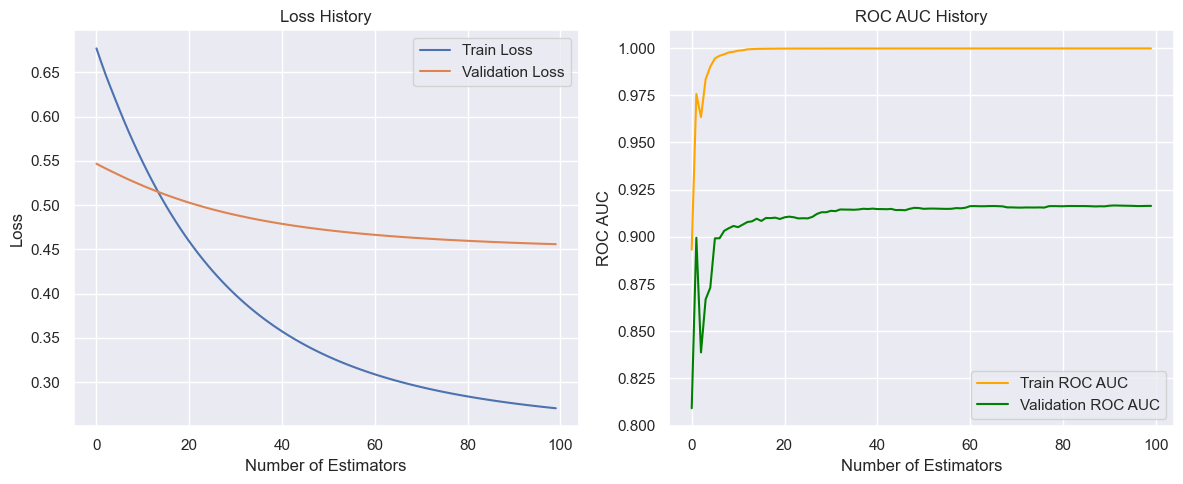

Train ROC-AUC: 0.9998
Valid ROC-AUC: 0.9164
Test ROC-AUC: 0.9141


In [53]:
boosting = Boosting(
    n_estimators=100,
    goss=True,
    subsample=0.3
)

boosting.fit(X_train, y_train, X_valid, y_valid)
boosting.plot_history()

print(f'Train ROC-AUC: {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC: {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC: {boosting.score(X_test, y_test):.4f}')

### 2.3. Работа с признаками (1 балл)

1. Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать `rsm`

2. С другой стороны, вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет. Для этого существует множество алгоритмов, мы предлагаем сделать два наиболее простых:

- $\text{Uniform}$. Значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- $\text{Quantile}$. Тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `colsample_bytree`, `tree_method` | `colsample_bytree`, `max_bin`| `rsm`, `quantize(...)`|

Нужно добавить параметры:
- `rsm: float | int = 1.0` — доля или число признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли
- `quantization_type: str | None = None` — тип квантизации, если она есть
- `nbins: int = 255` — число бинов для квантизации. Игнорируем, если тип квантизации не указан

<font color='plum'>**Вопрос**: как квантизация поможет в обработке выбросов и нанов?</font>

<font color='plum'>**Ответ**:  Квантизация помогает уменьшить влияние выбросов, сгруппировав экстремальные значения в один или несколько бинов, что предотвращает их чрезмерное воздействие на модель. </font>

<font color='plum'>**Вопрос**: можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?</font>

<font color='plum'>**Ответ**:  Да, можно заполнить отсутствующие значения NaN фиксированным числом.  Выбор конкретного числа имеет значение, поскольку некоторые значения могут вводить модель в заблуждение, если они пересекаются с реальными значениями признака.</font>

Total training time: 10.64 seconds


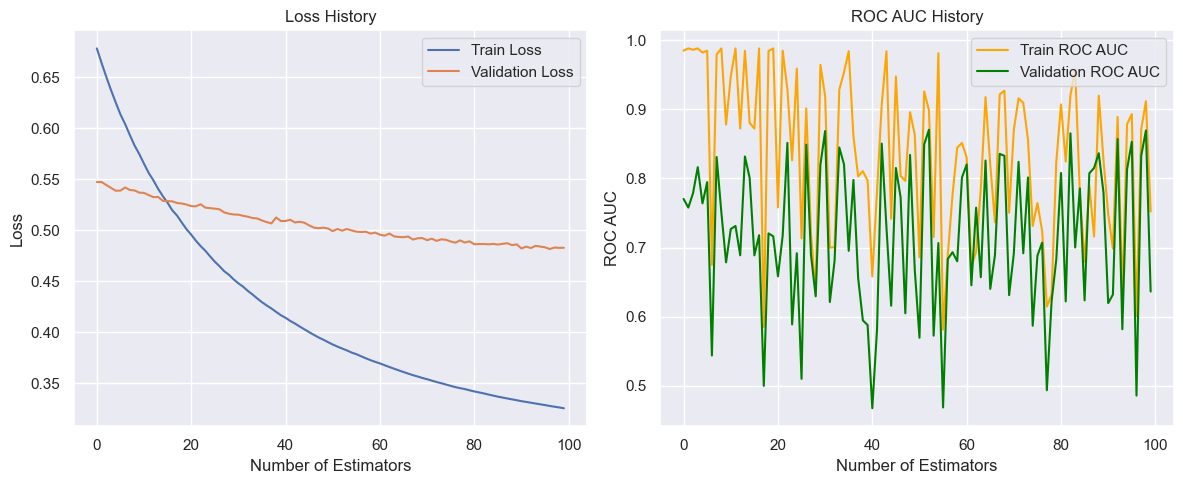

Train ROC-AUC: 0.5000
Valid ROC-AUC: 0.5137
Test ROC-AUC: 0.4861


In [52]:
boosting = Boosting(
    n_estimators=100,
    early_stopping_rounds=100,
    rsm=0.75,
    quantization_type='quantile',
    nbins=255
)

boosting.fit(X_train, y_train, X_valid, y_valid)
boosting.plot_history()

print(f'Train ROC-AUC: {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC: {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC: {boosting.score(X_test, y_test):.4f}')

### Бонус. Квантизация (1.5 балл)

В текущих имплементациях бустинга используются более сложные методы квантизации. К сожалению, способы выше страдают либо от неравноправности бинов — в каких-то объектов больше, в каких-то меньше, либо от того, что целевая переменная от бинов зависит опосредованно. Предлагается это исправить следующими способами:

1. $\text{MinEntropy}$. Это [один из методов](https://catboost.ai/docs/en/concepts/quantization), который используется для бинаризации в <font color='palegoldenrod'>**CatBoost**</font>, остальные на него очень похожи. Будем жадно набирать бины так, чтобы энтропия объектов внутри ($\sum_{i \in \text{bin}} x_i\log(x_i)$) была как можно меньше. Сделать такое разбиение руками непросто, но вам эта задача должна что-то напоминать
   
2. $\text{PiecewiseEncoding}$. Это относительно свежий метод для [табличных трансформеров](https://arxiv.org/pdf/2203.05556). Суть заключается в том, что бины для квантизации будем брать не с потолка, а именно те, что нужны для разбиения таргета. (В статье делается кодирование в вектор длины $T$, где $T$ число бинов, в нашем случае это излишне, бинов можно оставить столько же, но взять лмшь закодированную по формуле часть)

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| — | — | `feature_border_type="MinEntropy"` |

Нужно добавить опцию:

- `'MinEntropy'` для `quantization_type` — какую квантизацию используем

Реализуйте оба способа подсчета (или один, но тогда балл неполный) и сравните, удалось ли улучшить качество?

Total training time: 23.68 seconds


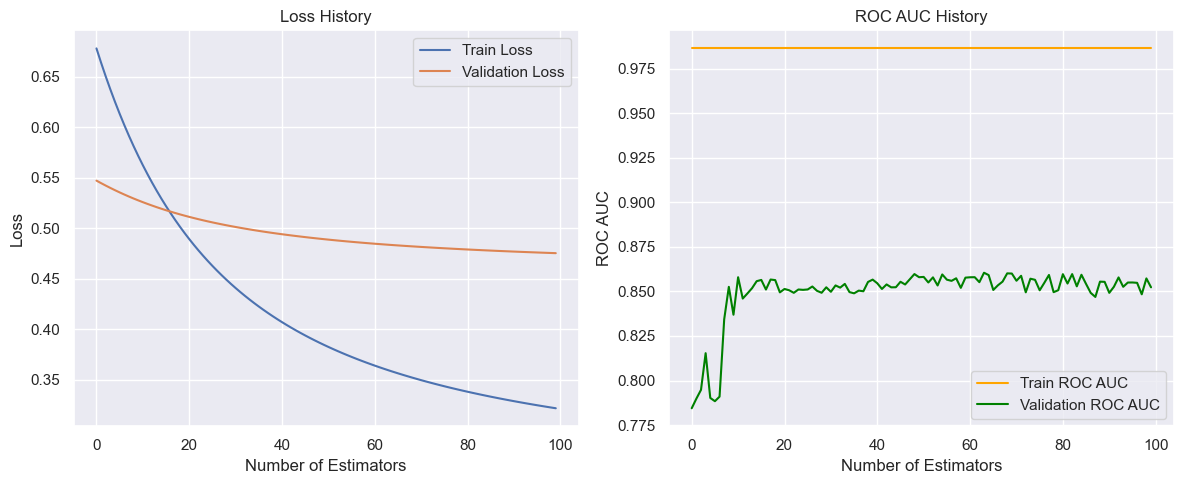

Train ROC-AUC: 0.5043
Valid ROC-AUC: 0.5052
Test ROC-AUC: 0.5053
Total training time: 73.54 seconds


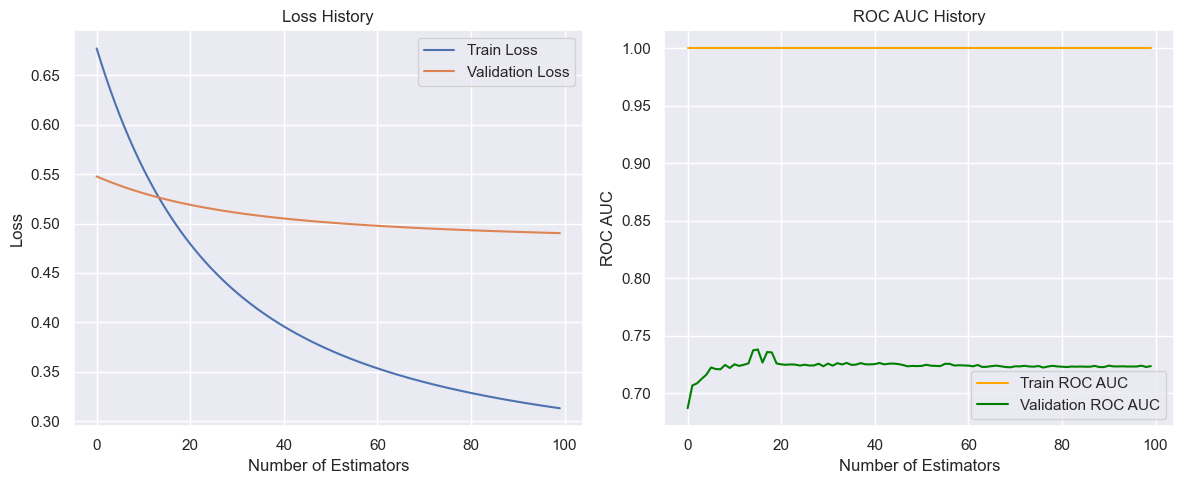

Train ROC-AUC: 0.5810
Valid ROC-AUC: 0.5731
Test ROC-AUC: 0.5859


In [74]:
for method in ['MinEntropy', 'PiecewiseEncoding']:
    boosting = Boosting(
        n_estimators=100,
        quantization_type=method,
        nbins=255
    )

    boosting.fit(X_train, y_train, X_valid, y_valid)
    boosting.plot_history()
    
    print(f'Train ROC-AUC: {boosting.score(X_train, y_train):.4f}')
    print(f'Valid ROC-AUC: {boosting.score(X_valid, y_valid):.4f}')
    print(f'Test ROC-AUC: {boosting.score(X_test, y_test):.4f}')

PiecewiseEncoding имеет более хороший аукрок, но время на обучение дольше.

### 2.4. Важность признаков (0.5 балла)

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor`), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными — иначе вы что-то сделали не так). Разумеется, способ не единственный, если хочется, посмотрите в документации

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `model.get_score()` | `lightgbm.importance()` | `model.get_feature_importance()` |

Допишите к бустингу:
- `feature_importances_` — атрибут, который возвращает важность признаков, согласно методу выше

Total training time: 28.50 seconds


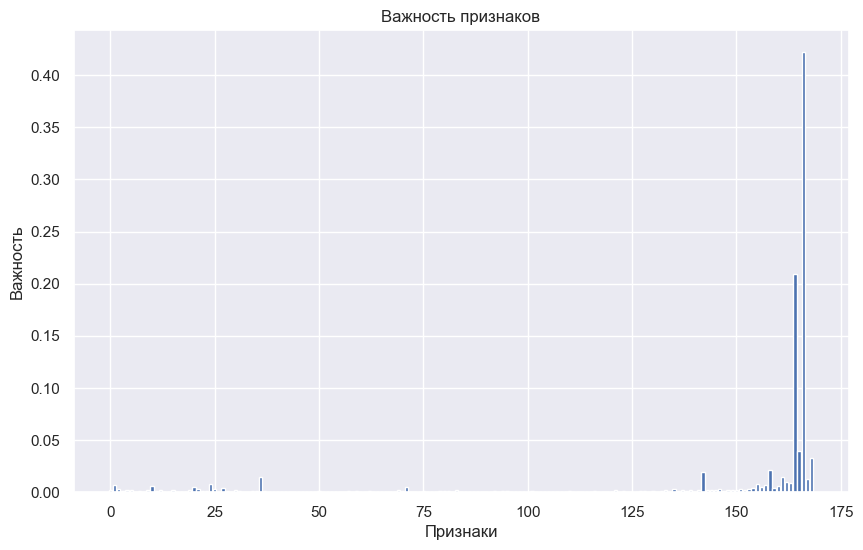

In [76]:
boosting = Boosting(
    n_estimators=100,
    goss=True,
    subsample=0.3
)

boosting.fit(X_train, y_train, X_valid, y_valid)
importances = boosting.feature_importances_

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances)
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Важность признаков')
plt.show()

Покажите, какие признаки оказались самыми важными

In [83]:
num_features = X_train.shape[1]
feature_names = [f'feature_{i+1}' for i in range(num_features)]

feature_importances = dict(zip(feature_names, importances))
sorted_features = sorted(feature_importances.items(), key=lambda item: item[1], reverse=True)
top_10_features = sorted_features[:10]
top_features_df = pd.DataFrame(top_10_features, columns=['Признак', 'Важность'])
top_features_df

,Признак,Важность
0,feature_167,0.421905
1,feature_165,0.209055
2,feature_166,0.039951
3,feature_169,0.032368
4,feature_159,0.021536
5,feature_143,0.019844
6,feature_37,0.014980
7,feature_162,0.014224
8,feature_168,0.013048
9,feature_163,0.010225


### Бонус. DART (1.5 балла)

Ранее мы обсуждали, что каждый базовый алгоритм пытается исправить ошибки всего предыдущего ансамбля. Из-за этого возникает неравноправие — каждая новая модель вносит все меньший и меньший вклад. Уверенные обучатели нейросетей знают, что это может привести к переобучению. Но выход есть, и выход этот [DART](https://arxiv.org/pdf/1505.01866)!

В DL есть такой вид регуляризации, как dropout, когда некоторые узлы нейросети со случайным шансом отключаются. Можно попробовать обобщить этот подход на случай бустингов и случайно выкидывать деревья из композиции во время обучения

1. Выбираем, какие деревья убрать. При подсчете антиградиента берем не весь ансамбль, а только ту часть, что осталась
2. Домножаем выходы дерева на $1/k$, где $k$ — число удаленных деревьев, чтобы учесть тот факт, что ансамбль был не весь. Тогда вклад отдельного дерева будет не настолько большим
3. Домножаем выходы выкинутых деревьев на $k/(k+1)$, чтобы масштабы выходов примерно совпадали

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `XGBClassifier(booster="dart")` | `LGBMClassifier(boosting_type="dart")` | — |

Параметры, которые нужно добавить:

- `dart: bool | None = False` — DART бустинг или нет
- `dropout_rate: int | float = 0.05` — доля деревьев, которую выкидываем во время обучения DART

Total training time: 35.84 seconds


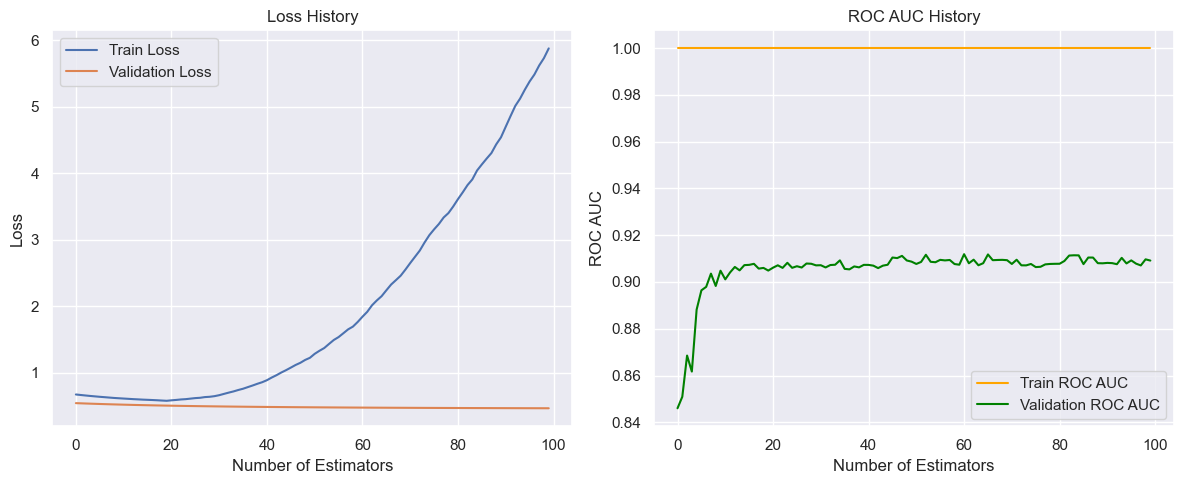

Train ROC-AUC: 0.9998
Valid ROC-AUC: 0.9092
Test ROC-AUC: 0.9068


In [114]:
from sklearn.tree import DecisionTreeRegressor

boosting = Boosting(
    base_model_class=DecisionTreeRegressor,
    n_estimators=100,
    learning_rate=0.1,
    dart=True,        
    dropout_rate=0.1,
    subsample=0.3, 
    bootstrap_type='Bernoulli'
)


boosting.fit(X_train, y_train, X_valid, y_valid)
boosting.plot_history()

print(f'Train ROC-AUC: {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC: {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC: {boosting.score(X_test, y_test):.4f}')

------

## Задание 3. Оптимизация (3.5 балла + 0.5 бонус)

Теперь давайте подумаем, как же правильно применять бустинги. Нас интересует: какие бустинги вообще бывают, как их правильно тюнить, и как интерпретировать

Оптимизация моделей с большим числом гиперпараметров это сложное дело. Нетрудно догадаться, что в случае, когда параметров $m$, сложность перебора в самом худшем случае будет порядка $n^m$. У бустингов, хотя на самом деле не только, эта проблема стоит особенно остро. Подумаем, как это делать умнее

### 3.1. Знакомство с optuna (1 балл)

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. В этом задании предлагается познакомиться с библиотекой [optuna](https://optuna.org/), которая делает перебор гиперпараметров легким и приятным, а также сохраняет всю историю экспериментов в одно место за вас

Подберите на валидации оптимальные значения следующих гиперпараметров для вашей реализации бустинга:
- `max_depth`
- `n_estimators`
- `learning_rate`
- любые другие параметры, которые вам понравились

Заметим, что оптуна это крайне гибкая библиотека, в которой можно реализовать абсолютно любую логику, которую пожелаете. За вас там есть лишь выбор модели. Чтобы не плодить несколько `objective`, можно слегка менять тело функции, например, добавить опциональные параметры, но шаблоном пользоваться не обязательно, как обычно

Подберите диапазон параметров самостоятельно, не забывайте фиксировать сид (нет, его не нужно перебирать). Сохраните и покажите оптимальный набор параметров. Сравните графики функций потерь для оптимального и дефолтного бустингов. Покажите, какие параметры дали наибольший прирост (для этого придется почитать документацию оптуны)

[I 2024-12-23 22:08:41,484] A new study created in memory with name: no-name-0074fda7-9af8-4197-a425-d4d628c8fff4
[I 2024-12-23 22:10:21,513] Trial 0 finished with value: 0.9154396475827186 and parameters: {'n_estimators': 218, 'learning_rate': 0.2536999076681771, 'subsample': 0.8659969709057025, 'dropout_rate': 0.2993292420985183}. Best is trial 0 with value: 0.9154396475827186.


Total training time: 99.94 seconds


[I 2024-12-23 22:10:55,416] Trial 1 finished with value: 0.9297851349701037 and parameters: {'n_estimators': 120, 'learning_rate': 0.01699897838270077, 'subsample': 0.5290418060840998, 'dropout_rate': 0.4330880728874676}. Best is trial 1 with value: 0.9297851349701037.


Total training time: 33.85 seconds


[I 2024-12-23 22:18:32,130] Trial 2 finished with value: 0.9241095980070768 and parameters: {'n_estimators': 321, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'dropout_rate': 0.48495492608099716}. Best is trial 1 with value: 0.9297851349701037.


...

Total training time: 188.96 seconds


[I 2024-12-23 22:35:05,536] Trial 8 finished with value: 0.9198277024950652 and parameters: {'n_estimators': 79, 'learning_rate': 0.25212679047779213, 'subsample': 0.9828160165372797, 'dropout_rate': 0.40419867405823057}. Best is trial 1 with value: 0.9297851349701037.


Total training time: 17.50 seconds


[I 2024-12-23 22:36:18,907] Trial 9 finished with value: 0.9216056729029326 and parameters: {'n_estimators': 187, 'learning_rate': 0.013940346079873234, 'subsample': 0.8421165132560784, 'dropout_rate': 0.22007624686980065}. Best is trial 1 with value: 0.9297851349701037.


Total training time: 73.30 seconds
Best params: {'n_estimators': 120, 'learning_rate': 0.01699897838270077, 'subsample': 0.5290418060840998, 'dropout_rate': 0.4330880728874676}
best ROC AUC: 0.9298
Total training time: 33.78 seconds


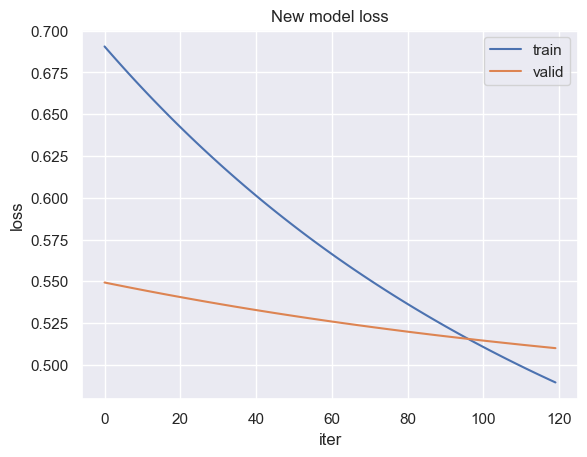

Total training time: 0.60 seconds
base model ROC AUC: 0.9096
Best model ROC AUC: 0.9252


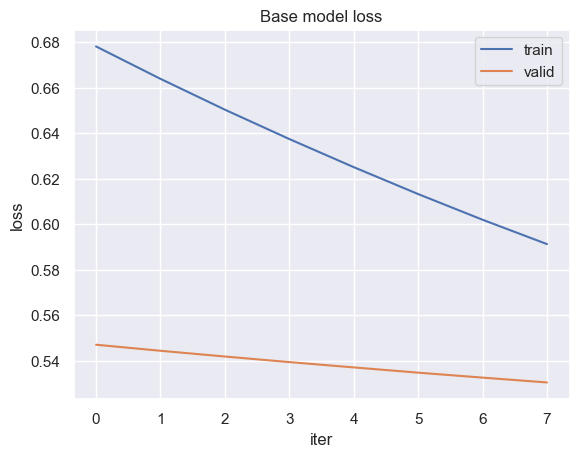

In [161]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification


def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    
    model = Boosting(
        base_model_class=DecisionTreeRegressor,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        subsample=subsample,
        dropout_rate=dropout_rate,
        dart=False
    )
    
    model.fit(X_train, y_train, X_valid, y_valid)
    
    y_pred_proba = model.predict_proba(X_valid)[:, 1]
    
    auc = roc_auc_score(y_valid, y_pred_proba)
    
    return auc


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=10)

best_params = study.best_params
best_score = study.best_value

print(f"Best params: {best_params}")
print(f"best ROC AUC: {best_score:.4f}")

default_model = Boosting(
    base_model_class=DecisionTreeRegressor,
    n_estimators=10,
    learning_rate=0.1,
    subsample=0.3,
    dropout_rate=0.0,
    early_stopping_rounds=3
)

model = Boosting(
    **best_params
)
model.fit(X_train, y_train, X_valid, y_valid)

def plot_loss_history(model, title):
    plt.plot(model.history["train_loss"], label='train')
    if "val_loss" in model.history:
        plt.plot(model.history["val_loss"], label='valid')
    plt.xlabel('iter')
    plt.ylabel('loss')
    plt.title(title)
    plt.legend()
    plt.show()

plot_loss_history(model, 'New model loss')



default_model.fit(X_train, y_train, X_valid, y_valid)
y_pred_proba_default = default_model.predict_proba(X_valid)[:, 1]
auc_default = roc_auc_score(y_valid, y_pred_proba_default)

print(f"base model ROC AUC: {auc_default:.4f}")
print(f'Best model ROC AUC: {model.score(X_test, y_test):.4f}')


plot_loss_history(default_model, 'Base model loss')

optuna.visualization.plot_param_importances(study)
plt.show()


### 3.2. Глубокая оптимизация (1 балл)

Помимо эффективного перебора гиперпараметров, `optuna` предлагает более тонкий контроль над самой процедурой обучения. Улучшите процедуру оптимизации следующим образом:

1. Посмотрите, как в `optuna` устроена запись в хранилища, и добавьте это в пайплайн оптимизации. Без указания БД все запуски оптуны сотрутся, как только закончится сессия. Более того, так можно распараллелить процесс оптимизации на несколько машин
2. Посмотрите, как можно контролировать процесс обучения бустинга при помощи прунера. У библиотечных имплементаций есть уже готовые, их можно использовать пунктом ниже. Для кастомной модели возьмите что-то из `optuna.pruners`. Идея прунера — не обучать бустинг до конца, если по истории видно, что другие бустинги на этом этапе статистически лучше.
3. Добавьте сохранение истории функции потерь и времени обучения в качестве `user_attribute` сразу в `study`. Мы не хотим оптимизировать их напрямую, но они нам понадобится для сравнения моделей в дальнейшем

Добавьте хранилище и юзер атрибуты и посмотрите, ускорилась ли оптимизация с добавлением прунера

[I 2024-12-23 23:00:12,118] Using an existing study with name 'boosting_optimization' instead of creating a new one.
[I 2024-12-23 23:02:05,226] Trial 10 finished with value: 0.9132079056027419 and parameters: {'n_estimators': 218, 'learning_rate': 0.2536999076681771, 'subsample': 0.8659969709057025, 'dropout_rate': 0.2993292420985183}. Best is trial 6 with value: 0.929151371332013.


Total training time: 112.99 seconds


[I 2024-12-23 23:02:44,090] Trial 11 finished with value: 0.9252669749280231 and parameters: {'n_estimators': 120, 'learning_rate': 0.01699897838270077, 'subsample': 0.5290418060840998, 'dropout_rate': 0.4330880728874676}. Best is trial 6 with value: 0.929151371332013.


Total training time: 38.79 seconds


[I 2024-12-23 23:06:50,738] Trial 12 finished with value: 0.9218638876849509 and parameters: {'n_estimators': 321, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'dropout_rate': 0.48495492608099716}. Best is trial 6 with value: 0.929151371332013.


...

Total training time: 10.04 seconds


[I 2024-12-23 23:17:18,087] Trial 18 finished with value: 0.9256688640864346 and parameters: {'n_estimators': 147, 'learning_rate': 0.02024223794867435, 'subsample': 0.7343526094439212, 'dropout_rate': 0.37109617606161127}. Best is trial 6 with value: 0.929151371332013.


Total training time: 55.06 seconds


[I 2024-12-23 23:20:37,234] Trial 19 finished with value: 0.9234941927615252 and parameters: {'n_estimators': 293, 'learning_rate': 0.051367327253586226, 'subsample': 0.5749111003838552, 'dropout_rate': 0.49800826587371777}. Best is trial 6 with value: 0.929151371332013.


Total training time: 198.96 seconds
Best params: {'n_estimators': 120, 'learning_rate': 0.01699897838270077, 'subsample': 0.5290418060840998, 'dropout_rate': 0.4330880728874676}
Best ROC AUC: 0.9292
Total training time: 37.46 seconds


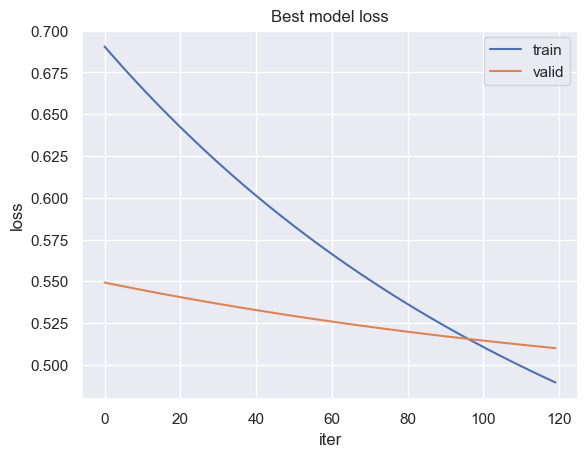

Total training time: 0.80 seconds
Base model ROC AUC: 0.9180


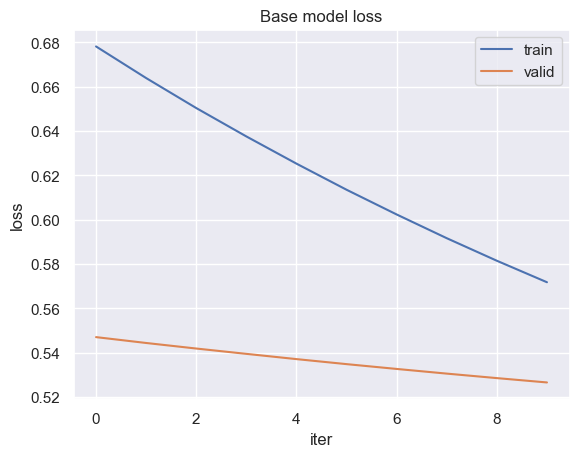

In [177]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
import time


def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    
    model = Boosting(
        base_model_class=DecisionTreeRegressor,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        subsample=subsample,
        dropout_rate=dropout_rate,
        dart=False
    )
    
    start_time = time.time()
    model.fit(X_train, y_train, X_valid, y_valid)
    end_time = time.time()
    
    y_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_pred_proba)
    
    trial.set_user_attr("train_loss_history", model.history.get("train_loss", []))
    trial.set_user_attr("valid_loss_history", model.history.get("val_loss", []))
    trial.set_user_attr("training_time", end_time - start_time)
    
    return auc

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
    storage='sqlite:///optuna_study.db',
    study_name='boosting_optimization',
    load_if_exists=True
)

study.optimize(objective, n_trials=10)

best_params = study.best_params
best_score = study.best_value

print(f"Best params: {best_params}")
print(f"Best ROC AUC: {best_score:.4f}")

best_model = Boosting(
    base_model_class=DecisionTreeRegressor,
    **best_params
)
best_model.fit(X_train, y_train, X_valid, y_valid)

def plot_loss_history(model, title):
    plt.plot(model.history["train_loss"], label='train')
    if "val_loss" in model.history:
        plt.plot(model.history["val_loss"], label='valid')
    plt.xlabel('iter')
    plt.ylabel('loss')
    plt.title(title)
    plt.legend()
    plt.show()

plot_loss_history(best_model, 'Best model loss')

default_model = Boosting(
    base_model_class=DecisionTreeRegressor,
    n_estimators=10,
    learning_rate=0.1,
    subsample=0.3,
    dropout_rate=0.0,
    early_stopping_rounds=3
)
default_model.fit(X_train, y_train, X_valid, y_valid)
y_pred_proba_default = default_model.predict_proba(X_valid)[:, 1]
auc_default = roc_auc_score(y_valid, y_pred_proba_default)

print(f"Base model ROC AUC: {auc_default:.4f}")


plot_loss_history(default_model, 'Base model loss')

optuna.visualization.plot_param_importances(study)
plt.show()


### 3.3. Готовые реализации (1 балл)

Библиотек для бустингов существует много, но активно используются лишь три. Ваша задача — попробовать их в деле, посмотреть на их уникальные фишки и понять, что вам нравится больше всего

Возьмите любую из популярных библиотек: <font color='lightblue'>`xgboost`</font>, <font color='lightgreen'>`lightgbm`</font>, <font color='palegoldenrod'>`catboost`</font>.
Ваша задача — взять одну из них, подобрать те же оптимальные параметры, что и выше, плюс что-то, что вам понравилось в них больше всего (может быть абсолютно любая фишка из пунктов выше или что-то, что вы найдете сами, не обязательно эксклюзивное), и сравнить две оптимизированные модели по
- динамике функции потерь (на обучающей и на валидационной выборке)
- времени обучения

In [175]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
import time
from IPython.display import clear_output


def objective_xgb(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'seed': 42
    }
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)
    
    start_time = time.time()
    evals_result = {}
    bst = xgb.train(param, dtrain, evals=[(dvalid, 'valid')], evals_result=evals_result, early_stopping_rounds=10, verbose_eval=False)
    end_time = time.time()
    
    preds = bst.predict(dvalid)
    auc = roc_auc_score(y_valid, preds)
    
    trial.set_user_attr("training_time", end_time - start_time)
    
    return auc

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
    storage='sqlite:///optuna_study_xgb.db',
    study_name='xgboost_optimization',
    load_if_exists=True
)
study_xgb.optimize(objective_xgb, n_trials=50)
clear_output()


Best params for XGBoost: {'n_estimators': 206, 'learning_rate': 0.2533318240730524, 'subsample': 0.7820941318331204, 'colsample_bytree': 0.584805168726576, 'max_depth': 10}
Best ROC AUC for XGBoost: 0.9444
[0]	valid-auc:0.86753
[1]	valid-auc:0.92334
[2]	valid-auc:0.92169
[3]	valid-auc:0.91911
[4]	valid-auc:0.92879
[5]	valid-auc:0.93150
[6]	valid-auc:0.93291
[7]	valid-auc:0.93361
[8]	valid-auc:0.93405
[9]	valid-auc:0.93472
{'valid': OrderedDict({'auc': [0.8675266376284788, 0.9233401419023924, 0.9216918775287688, 0.9191117251860383, 0.9287877953406399, 0.9314992500995743, 0.932907658083719, 0.9336124607190264, 0.934052663044476, 0.9347167579398052]})}


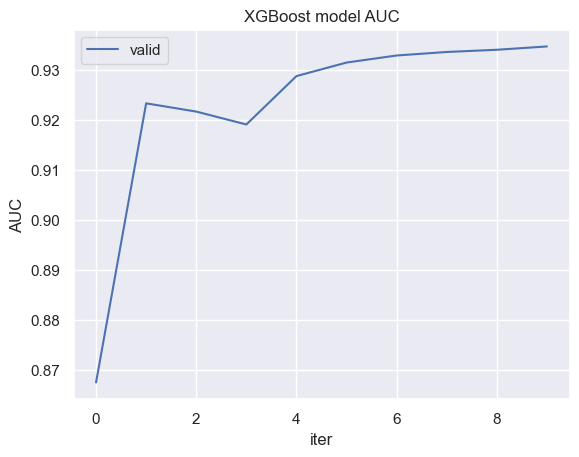

Training time for XGBoost model: 0.04 seconds


In [176]:
best_params_xgb = study_xgb.best_params
best_score_xgb = study_xgb.best_value

print(f"Best params for XGBoost: {best_params_xgb}")
print(f"Best ROC AUC for XGBoost: {best_score_xgb:.4f}")

dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)
evals_result = {}
best_params_xgb['eval_metric'] = 'auc'
best_model_xgb = xgb.train(best_params_xgb, dtrain, evals=[(dvalid, 'valid')], evals_result=evals_result, early_stopping_rounds=10)

print(evals_result)

def plot_xgb_loss_history(evals_result, title):
    plt.plot(evals_result['valid']['auc'], label='valid')
    plt.xlabel('iter')
    plt.ylabel('AUC')
    plt.title(title)
    plt.legend()
    plt.show()

plot_xgb_loss_history(evals_result, 'XGBoost model AUC')

training_time_xgb = study_xgb.best_trial.user_attrs['training_time']

print(f"Training time for XGBoost model: {training_time_xgb:.2f} seconds")

<font color='plum'>**Вопрос:** Какая архитектура вам нравится больше всего и почему?</font>

<font color='plum'>**Ответ**: XGBoost — это одна из моих любимых архитектур, особенно в контексте задач классификации и регрессии. Она основана на методе градиентного бустинга, который строит ансамбль слабых моделей и объединяет их для улучшения общей производительности. </font>

### Бонус. Random Forest (0.5 балла)

Если очень захотеть, оптуна может оптимизировать все, что угодно, даже нейросети. Давайте противопоставим бустингу его злейшего врага — алгоритм Random Forest.

Возьмите реализацию случайного леса из <font color='lightgreen'>`lightgbm`</font>. Посмотрите, какие там есть гиперпараметры, переберите что-либо из них вместе с `max_depth` и `n_estimators`.

Сравните его качество и динамику функции потерь (на обучающей и на валидационной выборке) с таковыми у бустинга и сделайте вывод, а нужен ли Random Forest?

In [ ]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

### 3.4. Бустинг и вероятности (0.5 балла)

С качеством мы более-менее разобрались, но что насчет вероятностей? Постройте калибровочную кривую для вашей лучшей модели бустинга. Насколько хорошо бустинг оценивает вероятности?

In [ ]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚


Постройте также калибровочную кривую для логистической регрессии, сравните их между собой. Проанализируйте полученные результаты.

In [ ]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

## Социализационный бонус. Новогоднее 🎆 (0.5 балла)

Сфотографируйтесь с наряженной новогодней или рождественской ёлкой! Приложите фотографию, опишите свои впечатления, чего вы ждете от нового 2025 года?

In [135]:
from IPython.display import Image, display
display(Image(filename='/Users/tanpeter/Desktop/IMG_4499.jpg'))

# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚